In [1]:
import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import importlib
importlib.reload(PKA.genPKA_Dynamics)
importlib.reload(PKA)

<module 'PKA_Sleep' from '/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/__init__.py'>

In [2]:
experiment_names = ['ltFLiPAKARmemEEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0010',
                    'dgFLiPmemAKAREEGEMG0003',
                    'dgFLiPmemAKAREEGEMG0008',
                    'ltFLiPAKARmemEEGEMG0036',
                    'ltFLiPAKARmemEEGEMG0043',
                    'kgFLiPAKAREEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0055',
                    'ltFLiPAKARmemEEGEMG0068',
                    'ltFLiPAKARmemEEGEMG0072',
                    'ltFLiPAKARmemEEGEMG0085',
                    'ltFLiPAKARmemEEGEMG0090-1',
                    'ltFLiPAKARmemEEGEMG0094',
                    'ltFLiPAKARmemEEGEMG0097-1',
                    'ltFLiPAKARmemEEGEMG0098-1',
                    'ltFLiPAKARmemEEGEMG0099-1',
                    'ltFLiPAKARmemEEGEMG0099-2',
                    'ltFLiPAKARmemEEGEMG0100-1',
                    'ltFLiPAKARmemEEGEMG0101-1',
                    'ltFLiPAKARmemEEGEMG0102-1',
                    'ltFLiPAKARmemEEGEMG0103-1',
                    'kgFLiPAKAREEGEMG0018',
                    'kgFLiPAKAREEGEMG0019',
                    'kgFLiPAKAREEGEMG0020']
mouse_names = ['3825',
                '3825',
                '3825',
                '3825',
                '4346-t5-7',
                '4346-t5-7',
                '4507',
                '4502',
                '4507',
                '4610',
                '4713',
                '4769',
                '4775',
                '5782',
                '5007',
                '5075',
                '5075',
                '5078',
                '5046',
                '5047',
                '5076',
                '5582',
                '5583',
                '5577']

In [3]:
epoch_len = 4
filter_bounds = [None, None] #Add high and low pass cutoffs here if you want to filter the photometry data
binned = False #True or False for using binned vs. unbinned photometry data
shuffle_window = 200 #The size of the chunk used for shuffling the photometry data; usually 200
experimental_sensor = 'FLIM-mAKAR' #label for the sensor used in this experiment (e.g. FLIM-AKAR, FLIM-mAKAR, T391A)
sleep_states = True #True or False - include sleep sco}res in the class
microarousals = True #True or False - microarousals as a different sleep state
seperate_acqs = False #True or False - Also build a class for each acquisition of an experiment
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/' #The directory above the raw data folder

df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]
baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, pull_baseline = True, 
                                          baseline_idxs = baseline_idxs)

FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                    exclude_acqs = excluded_acqs)

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_65570/1169005652.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this expe

In [4]:
figure_dir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_6/'
brain_region = 'mPFC'
transition_types = 'NREM-Wake'
fig_ext = '.ps'
fn = brain_region+'_'+transition_types+'_deltapower_NREM-Wake'+fig_ext
savedir = os.path.join(figure_dir, fn)

In [5]:
FLP_classes = FLP_classes_dict['Experiment Classes']
experiment_names = FLP_classes_dict['Experiment Names']
mouseID = FLP_classes_dict['Animal Names']
zscore = True
diff_wake = False
these_transitions = ['NREM-Wake']
remove_short = False
EEG_chan = 0
downsamp_EEG = True
window_length = 10
noverlap = 9
window_type = None
norm = False
window = [300,30]
freq_dict = {'Delta': [0.5, 4]}
intensity = False
diff_wake = False
shuffled = False
long_short_wake = False
long_short_NREM = False
NREM_cutoff = 70
wake_cutoff = 70
allow_nextstate = False
raw_lifetime = False
just_dictionary = True
P2_dict = PKA.transition_triggered_lifetime(FLP_classes, experiment_names, mouseID, window = window, savedir = False, 
                                                  these_transitions = these_transitions,intensity = intensity, diff_wake = diff_wake, 
                                                  shuffled = shuffled, long_short_wake = long_short_wake, long_short_NREM = long_short_NREM,
                                                  NREM_cutoff = NREM_cutoff, wake_cutoff = wake_cutoff, allow_nextstate = allow_nextstate,
                                                  raw_lifetime = raw_lifetime, just_dictionary = just_dictionary, 
                                                  remove_short = remove_short, zscore = zscore)

power_dict = PKA.transition_triggered_power(FLP_classes, experiment_names, mouseID, window = window, freq_dict = freq_dict,
                                        	these_transitions = these_transitions, diff_wake = diff_wake, remove_short = remove_short, 
                                            EEG_chan = EEG_chan, downsamp_EEG = downsamp_EEG, window_length = window_length, 
                                            noverlap = noverlap, window_type = window_type, norm = norm)

Working on ltFLiPAKARmemEEGEMG0009...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0010...
NREM-Wake
Working on dgFLiPmemAKAREEGEMG0003...
NREM-Wake
Working on dgFLiPmemAKAREEGEMG0008...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0036...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0043...
NREM-Wake
Working on kgFLiPAKAREEGEMG0009...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0055...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0068...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0072...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0085...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0090-1...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0094...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0097-1...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0098-1...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0099-1...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0099-2...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0100-1...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0101-1...
NREM-Wake
Working on ltFLiPAKARmemEEGEMG0102-1...
NREM-Wake
Working on ltFLiPAKARmemEEG

/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:740: RuntimeWarning: Mean of empty slice
  all_dicts[a]['Average ' + data_key] = {g: {s: average_function(np.concatenate(all_dicts[a][data_key][g][s], axis = 0), axis = 0)
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:439: RuntimeWarning: Mean of empty slice
  y = average_function(these_lifetimes, axis = 0) # Compute average based on inputted function.
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:440: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  err = error_function(these_lifetimes, axis = 0, nan_policy='omit')  # Compute error based on inputted function.
/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/memPKA_Dynamics.py:1064: RuntimeWarning: All-NaN slic

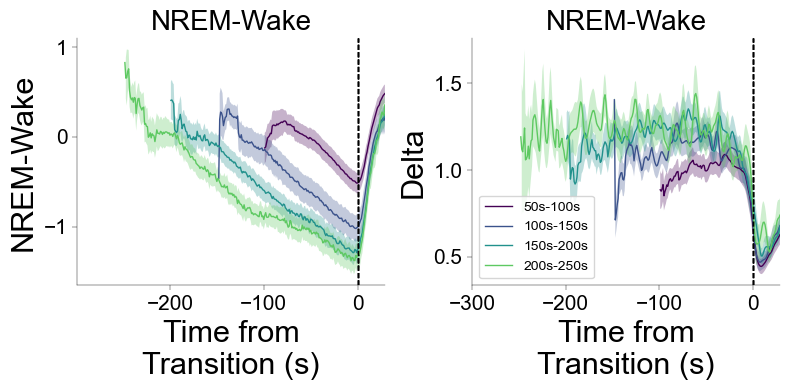

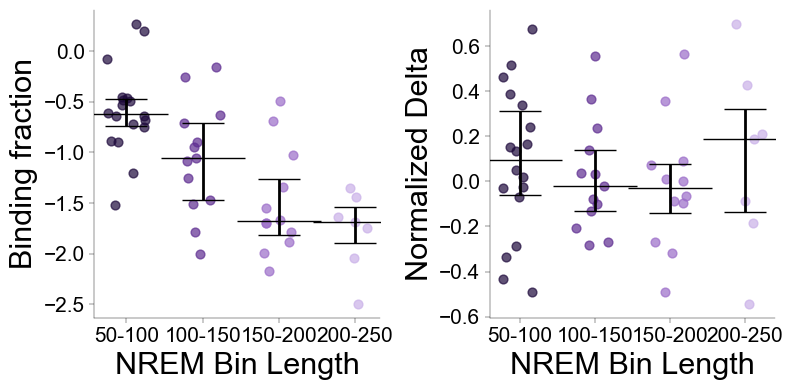

In [6]:
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_6/'
bin_edges = np.arange(50, 300, 50)
color_list = ['#1E0A3C', '#5E2D91', '#9B6CC8', '#C9B0E8']
fig, ax, quant_dict = PKA.plot_binned_power_p2(P2_dict, power_dict, bin_edges, transition_type = 'NREM-Wake', 
                                   norm_val = np.nanmean(np.concatenate(power_dict['Power']['Delta']['NREM-Wake'])), 
                                               cmap_name = 'viridis', color_list=color_list)

h, l = ax[0].get_legend_handles_labels()
l = [str(bin_edges[i]) + 's-' + str(bin_edges[i+1]) + 's' for i in range(len(bin_edges)-1)]
ax[1].legend(handles = h, labels = l)
graph.thick_axes(fig, ax, width = 0.3)
fig.tight_layout()
quant_fig, quant_ax = plt.subplots(ncols = 2, figsize = [8, 4])    
power_scatter = [quant_dict[k]['Power']['Difference'] for k in quant_dict.keys()]
p2_scatter = [quant_dict[k]['Lifetime']['Difference'] for k in quant_dict.keys()]
graph.swarm_plot(quant_fig, quant_ax[0], p2_scatter, range(0, len(list(quant_dict.keys()))), color_list, edgecolors=None, 
                    x_width=0.25, avg_type='median', percentiles=[25, 75], x_labels=list(quant_dict.keys()), ylabel=None, capsize=15, 
                 markersize=60, alpha=0.7, scatter_size=40, match_ebarcolor=False, legend_labels=None)
graph.swarm_plot(quant_fig, quant_ax[1], power_scatter, range(0, len(list(quant_dict.keys()))), color_list, edgecolors=None, 
                    x_width=0.25, avg_type='median', percentiles=[25, 75], x_labels=list(quant_dict.keys()), ylabel=None, capsize=15, 
                 markersize=60, alpha=0.7, scatter_size=40, match_ebarcolor=False, legend_labels=None)
graph.thick_axes(quant_fig, quant_ax, width = 0.3)
graph.label_axes(quant_ax[0], x = 'NREM Bin Length', y = 'Binding fraction')
graph.label_axes(quant_ax[1], x = 'NREM Bin Length', y = 'Normalized Delta')
quant_fig.tight_layout()
quant_fig.savefig(os.path.join(fig_savedir, 'mPFC_scatter.ps'))
fig.savefig(os.path.join(fig_savedir, 'mPFC_deltaaverages_norm_NREM.ps'))

In [7]:
from statsmodels.stats import multitest
stats_dict = {str(bin_edges[b]) + '-' + str(bin_edges[b+1]):{
        'P2': {
            '1-sample wilcoxon': stats.wilcoxon(p2_scatter[b], alternative='less'),
            'mannwhitu': stats.mannwhitneyu(p2_scatter[b], p2_scatter[b+1], alternative='greater')},
        'Power': {
            '1-sample wilcoxon': stats.wilcoxon(power_scatter[b], alternative='less'),
            'mannwhitu': stats.mannwhitneyu(power_scatter[b], power_scatter[b+1], alternative='greater')}} 
            for b in range(len(power_scatter)-1)}
stats_dict[str(bin_edges[-2]) + '-' + str(bin_edges[-1])] = {'P2': {'1-sample wilcoxon': stats.wilcoxon(p2_scatter[-1], 
                                                                                                       alternative='less')},
                                                             'Power': {'1-sample wilcoxon': stats.wilcoxon(power_scatter[-1], 
                                                                                                       alternative='less')}}

# for b in range(len(bin_edges)-1):
#     stats_dict[str(bin_edges[b]) + '-' + str(bin_edges[b+1])]['P2']['bonferonni'] =  multitest.multipletests(
#         stats_dict[str(bin_edges[b]) + '-' + str(bin_edges[b+1])]['P2']['mannwhitu'], alpha=0.05, method='bonferroni')[1]
#     stats_dict[str(bin_edges[b]) + '-' + str(bin_edges[b+1])]['Power']['bonferonni'] = multitest.multipletests(
#         stats_dict[str(bin_edges[b]) + '-' + str(bin_edges[b+1])]['Power']['mannwhitu'], alpha=0.05, method='bonferroni')[1]


In [12]:
for k in stats_dict.keys():
    print(k + ':' + str(stats_dict[k]['Power']['1-sample wilcoxon'].pvalue))

50-100:0.8581352233886719
100-150:0.5269775390625
150-200:0.3955078125
200-250:0.8125
